# GISLR — does each sign have a kinematic "pattern"? Intra- vs inter-gloss similarity (TODO §3.8)

**Dataset-stage diagnostic. No model is trained.** The user's question (2026-09-25): compute a small set of
interpretable variables per clip and check two things across **all 250 glosses**. Are clips of the same
gloss similar? Are different glosses dissimilar? If both hold, each sign generalizes to a pattern.

Per clip (`sb.recognize.patterns.clip_descriptors`, the user's 7 steps):
1. every point minus the mid-shoulder point (reference point);
2. ÷ the clip's median shoulder width (scale);
3. elbow, shoulder and wrist angles, each side;
4. distances: hand ↔ hand, each hand ↔ face (nose tip), each hand ↔ chest (mid-shoulder);
5. null frames dropped (no shoulders, or no hand at all); a hand missing in a kept frame stays NaN;
6. variance of displacement, velocity, acceleration and jerk (derivative orders 0–3) of every point per
   axis, and of every pair distance;
7. touch counts: hand–hand and hand–face contact onsets.

Each variable set is computed in four axis settings the user asked for (**`x` only, `y` only, `z` only,
`xyz`**) plus `xy`, the setting every model here uses. Angles need at least 2 axes, so the single-axis runs
have no angle family.

**Tests**, per axis setting × variable family:
- **intra / inter**: mean cosine similarity of two clips of the same gloss vs two clips of different
  glosses (standardized variables);
- **separable glosses**: share of glosses whose own clips are more alike than they are to the closest
  other gloss;
- **silhouette** (cosine, glosses as clusters; 1 = perfect patterns, 0 = overlapping, < 0 = wrong);
- **nearest template**: one mean-descriptor template per gloss from `train.csv`, every `test.csv` clip
  assigned to the most similar template. Top-1/top-5 against chance of 0.4%. This checks whether the
  pattern generalizes, with no fitted weights.
- **Fisher ratio** per variable: between-gloss variance / within-gloss variance.

| artifact | path |
|---|---|
| descriptors, one parquet per chunk (resumable) | `data/cache/gislr/sign_patterns/descriptors/chunk_<k>.parquet` |
| every test result | `data/cache/gislr/sign_patterns/results.json`, `results.csv` |
| per-variable Fisher ratios | `data/cache/gislr/sign_patterns/fisher.csv` |
| per-gloss table | `data/cache/gislr/sign_patterns/per_gloss.csv` |
| figures | `data/cache/gislr/sign_patterns/assets/*.png` |

**Resumable:** a chunk whose parquet exists is skipped; §3 reads only the parquets.
Related earlier work: `docs/reports/feature-discriminability.md` (a trained logistic probe on 15 glosses)
and `pair-similarity.md`. This notebook covers all 250 glosses, the user's variables, and uses no fitted model.

## 1. Setup

In [1]:
# ============================================================
# Imports, tunables, paths
# ============================================================
import json
import os
from concurrent.futures import ProcessPoolExecutor
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, gislr_dir
from sb.recognize import patterns as PT

AXES = ("x", "y", "z", "xy", "xyz")  # the user's x / y / z / xyz, plus xy (what the models use)
TOUCH_THR = 0.12      # contact below 0.12 shoulder widths (~5 cm); ends above 1.5x that
CHUNK = 5000          # clips per resumable chunk
WORKERS = 12          # processes for descriptor extraction
FAMILY_SETS = {       # what each test row compares
    "angle": ("angle",),
    "distance": ("distance",),
    "touch": ("touch",),
    "angle+distance+touch": ("angle", "distance", "touch"),  # the user's variables combined
    "kinematics": ("kinematics",),
    "all": ("angle", "distance", "touch", "kinematics"),
}

DATA = gislr_dir()
OUT = CACHE_DIR / "gislr" / "sign_patterns"
DESC = OUT / "descriptors"
ASSETS = OUT / "assets"
for d in (DESC, ASSETS):
    d.mkdir(parents=True, exist_ok=True)
CLIPS = pd.concat([pd.read_csv(DATA / "train.csv"), pd.read_csv(DATA / "test.csv")], ignore_index=True)
print(f"GISLR: {DATA}\n{len(CLIPS)} clips ({(CLIPS.split == 'train').sum()} train / {(CLIPS.split == 'test').sum()} test), "
      f"{CLIPS.sign.nunique()} glosses\nresults -> {OUT}")

GISLR: C:\Users\user2\.cache\kagglehub\datasets\bracu23101281\gislr-stratified\versions\1
94477 clips (75581 train / 18896 test), 250 glosses
results -> C:\Users\user2\repository\data\cache\gislr\sign_patterns


## 2. Descriptors for every clip (steps 1–7)

In [2]:
# ============================================================
# Every clip x every axis setting; one parquet per chunk (resumable)
# ============================================================
fn = partial(PT.file_descriptors, axes=AXES, touch_thr=TOUCH_THR)
chunks = [(k, CLIPS.iloc[s:s + CHUNK]) for k, s in enumerate(range(0, len(CLIPS), CHUNK))]
todo = [(k, c) for k, c in chunks if not (DESC / f"chunk_{k:03d}.parquet").exists()]
bar = tqdm(total=sum(len(c) for _, c in todo), desc="descriptors")
with ProcessPoolExecutor(WORKERS) as ex:
    for k, c in todo:
        rows = []
        for r in ex.map(fn, [str(DATA / p) for p in c.npz_relpath], chunksize=64):
            rows.append(r)
            bar.update()
        t = pd.DataFrame(rows, index=c.index)
        t.insert(0, "sign", c.sign.to_numpy())
        t.insert(1, "split", c.split.to_numpy())
        t.insert(2, "participant_id", c.participant_id.to_numpy())
        tmp = DESC / f"chunk_{k:03d}.tmp.parquet"
        t.to_parquet(tmp)
        os.replace(tmp, DESC / f"chunk_{k:03d}.parquet")
bar.close()
TABLE = pd.concat([pd.read_parquet(p) for p in sorted(DESC.glob("chunk_*.parquet"))]).sort_index()
assert len(TABLE) == len(CLIPS)
print(TABLE.shape, "· null frames dropped:",
      f"{1 - TABLE['xyz|meta:n_kept'].sum() / TABLE['xyz|meta:n_frames'].sum():.1%}",
      "· clips with no usable frame:", int((TABLE['xyz|meta:n_kept'] == 0).sum()))

descriptors:   0%|          | 0/94477 [00:00<?, ?it/s]

(94477, 590) · null frames dropped: 39.1% · clips with no usable frame: 0


## 3. Intra- vs inter-gloss similarity, per axis setting × variable family

`similarity_report` runs on all `train.csv` clips, and `nearest_template` goes train → test. `dominant` is
the same test after relabeling each clip so "right" means the hand seen more often. GISLR has left-handed
signers, whose clips otherwise look like a different sign.

In [3]:
# ============================================================
# Every test; results.json / results.csv
# ============================================================
TABLE = pd.concat([pd.read_parquet(p) for p in sorted(DESC.glob("chunk_*.parquet"))]).sort_index()
usable = TABLE["xyz|meta:n_kept"] > 0
tr = (TABLE.split == "train") & usable
te = (TABLE.split == "test") & usable
rows, per_gloss, fisher = [], {}, {}
for axes in tqdm(AXES, desc="axis settings"):
    for hand in ("as labeled", "dominant"):
        t = TABLE if hand == "as labeled" else PT.dominant_swap(TABLE, axes)[0]
        sub = t[[c for c in t.columns if c.startswith(f"{axes}|")]]
        sub.columns = [c.split("|", 1)[1] for c in sub.columns]
        for fam, fams in FAMILY_SETS.items():
            X, cols = PT.feature_matrix(sub, fams)
            if not cols:
                continue  # angles on a single axis
            y = t.sign.to_numpy()
            rep = PT.similarity_report(X[tr.to_numpy()], y[tr.to_numpy()])
            nt = PT.nearest_template(X[tr.to_numpy()], y[tr.to_numpy()], X[te.to_numpy()], y[te.to_numpy()])
            F = PT.fisher_ratio(X[tr.to_numpy()], y[tr.to_numpy()])
            rows.append({"axes": axes, "hand": hand, "family": fam, "n_vars": len(cols),
                         **{k: v for k, v in rep.items() if k != "per_gloss"}, **nt,
                         "fisher_median": float(np.median(F)), "fisher_max": float(F.max())})
            if hand == "dominant":
                per_gloss[f"{axes}/{fam}"] = rep["per_gloss"]
                fisher[f"{axes}/{fam}"] = dict(zip(cols, F.tolist()))
RES = pd.DataFrame(rows)
RES.to_csv(OUT / "results.csv", index=False)
tmp = OUT / "results.tmp.json"
tmp.write_text(json.dumps({"results": rows, "per_gloss": per_gloss}, indent=1))
os.replace(tmp, OUT / "results.json")
pd.DataFrame([{"setting": k, "variable": v, "fisher": f} for k, d in fisher.items() for v, f in d.items()]) \
    .to_csv(OUT / "fisher.csv", index=False)
show = ["axes", "hand", "family", "n_vars", "intra", "inter", "nearest_inter", "frac_glosses_separable",
        "silhouette", "top1", "top5", "fisher_median"]
print(RES[show].to_string(index=False, float_format="{:.3f}".format))

axis settings:   0%|          | 0/5 [00:00<?, ?it/s]

axes       hand               family  n_vars  intra  inter  nearest_inter  frac_glosses_separable  silhouette  top1  top5  fisher_median
   x as labeled             distance      20  0.164  0.035          0.210                   0.032      -0.204 0.015 0.069          0.042
   x as labeled                touch       5  0.035  0.024          0.052                   0.012      -0.159 0.004 0.023          0.010
   x as labeled angle+distance+touch      25  0.099  0.019          0.130                   0.020      -0.141 0.014 0.070          0.039
   x as labeled           kinematics      44  0.125  0.089          0.172                   0.032      -0.161 0.013 0.057          0.019
   x as labeled                  all      69  0.099  0.038          0.125                   0.060      -0.118 0.024 0.093          0.023
   x   dominant             distance      10  0.306  0.066          0.396                   0.020      -0.453 0.020 0.086          0.062
   x   dominant                touch     

## 4. Which variables carry the pattern (Fisher ratio, dominant-hand `xyz`)

In [4]:
# ============================================================
# Top and bottom variables by between/within-gloss variance
# ============================================================
FI = pd.read_csv(OUT / "fisher.csv")
f = FI[FI.setting == "xyz/all"].sort_values("fisher", ascending=False)
f["family"] = f.variable.str.split(":").str[0]
print("top 20:\n" + f.head(20).to_string(index=False, float_format="{:.3f}".format))
print("\nmedian Fisher ratio by family:\n" + f.groupby("family").fisher.describe()[["count", "50%", "max"]].to_string())
by_axis = (FI[FI.setting.str.endswith("/all")].assign(axes=lambda d: d.setting.str.split("/").str[0])
           .groupby("axes").fisher.median())
print("\nmedian Fisher ratio by axis setting (all variables):\n" + by_axis.to_string())

top 20:
setting                           variable  fisher     family
xyz/all                 touch:rh_face_frac   0.910      touch
xyz/all                touch:rh_face_count   0.529      touch
xyz/all              distance:rh_face_mean   0.495   distance
xyz/all kinematics:rh_index_tip_x_disp_var   0.170 kinematics
xyz/all  kinematics:rh_centroid_x_disp_var   0.163 kinematics
xyz/all      kinematics:r_elbow_y_disp_var   0.157 kinematics
xyz/all      kinematics:r_wrist_y_disp_var   0.147 kinematics
xyz/all  kinematics:rh_centroid_y_disp_var   0.123 kinematics
xyz/all                 angle:r_wrist_mean   0.110      angle
xyz/all kinematics:rh_index_tip_y_disp_var   0.097 kinematics
xyz/all      kinematics:r_wrist_x_disp_var   0.085 kinematics
xyz/all             distance:rh_chest_mean   0.070   distance
xyz/all  kinematics:rh_index_tip_x_vel_var   0.065 kinematics
xyz/all          distance:rh_face_disp_var   0.061   distance
xyz/all             angle:r_wrist_disp_var   0.060      angle


## 5. Per gloss: which signs have a tight, distinct pattern

In [5]:
# ============================================================
# Per-gloss silhouette and nearest rival (dominant-hand xyz, the user's combined variables)
# ============================================================
R = json.loads((OUT / "results.json").read_text())["per_gloss"]
key = "xyz/angle+distance+touch"
PG = pd.DataFrame(R[key]).sort_values("silhouette", ascending=False)
PG["margin"] = PG["intra"] - PG["nearest_inter"]
PG.to_csv(OUT / "per_gloss.csv", index=False)
cols = ["gloss", "silhouette", "intra", "nearest_inter", "nearest_gloss", "margin"]
print(f"{key}: glosses with positive mean silhouette {(PG.silhouette > 0).mean():.1%}, "
      f"intra > nearest rival {(PG.margin > 0).mean():.1%}")
print("\nmost pattern-like:\n" + PG[cols].head(12).to_string(index=False, float_format="{:.3f}".format))
print("\nleast pattern-like:\n" + PG[cols].tail(12).to_string(index=False, float_format="{:.3f}".format))

xyz/angle+distance+touch: glosses with positive mean silhouette 0.0%, intra > nearest rival 7.2%

most pattern-like:
  gloss  silhouette  intra  nearest_inter nearest_gloss  margin
   shhh      -0.032  0.228          0.209        orange   0.019
 minemy      -0.044  0.149          0.132          have   0.017
   have      -0.046  0.159          0.145        animal   0.014
  clown      -0.057  0.220          0.210          duck   0.010
   chin      -0.063  0.178          0.181          shhh  -0.003
 jacket      -0.067  0.145          0.141          have   0.004
 animal      -0.073  0.141          0.145          have  -0.003
   lion      -0.075  0.096          0.074           hat   0.021
   frog      -0.077  0.194          0.203          shhh  -0.009
fireman      -0.078  0.130          0.094           boy   0.036
   duck      -0.081  0.213          0.211          bird   0.002
   bird      -0.081  0.209          0.211          duck  -0.002

least pattern-like:
      gloss  silhouette  intra

## 6. Figures

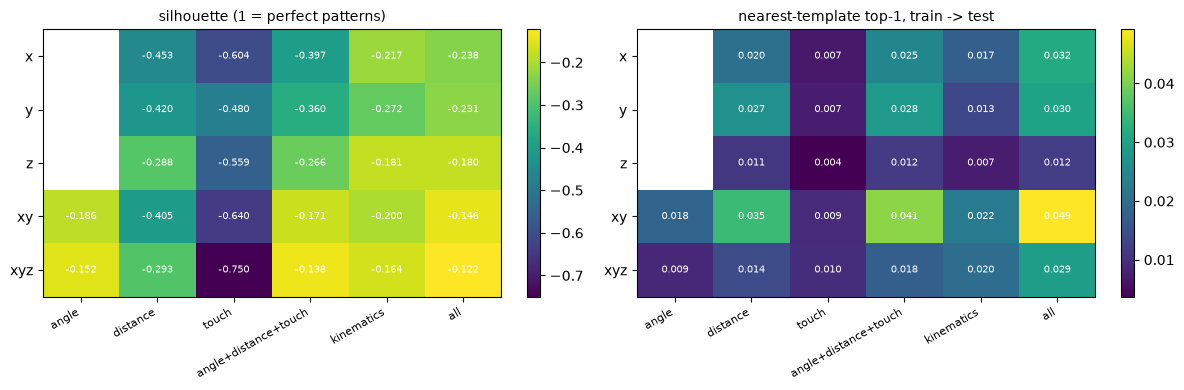

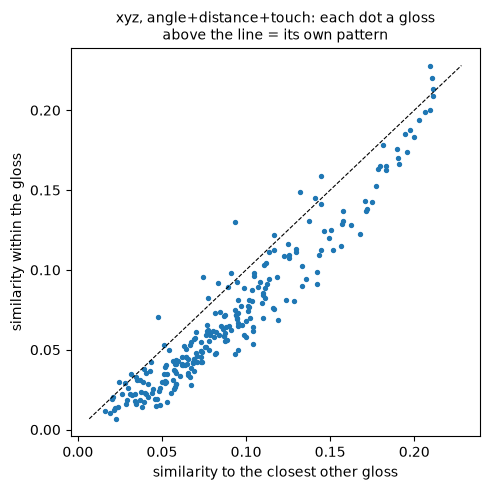

In [6]:
# ============================================================
# Silhouette + template accuracy per axis setting x family; per-gloss intra vs rival
# ============================================================
RES = pd.read_csv(OUT / "results.csv")
d = RES[RES.hand == "dominant"]
fams = list(FAMILY_SETS)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in ((axs[0], "silhouette", "silhouette (1 = perfect patterns)"),
                          (axs[1], "top1", "nearest-template top-1, train -> test")):
    M = d.pivot(index="axes", columns="family", values=metric).reindex(index=list(AXES), columns=fams)
    im = ax.imshow(M.to_numpy(dtype=float), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(fams)), fams, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(AXES)), AXES)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color="w")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(ASSETS / "grid.png", dpi=130)
plt.show()

PG = pd.read_csv(OUT / "per_gloss.csv")
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(PG.nearest_inter, PG.intra, s=8)
lim = [min(PG.nearest_inter.min(), PG.intra.min()), max(PG.nearest_inter.max(), PG.intra.max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("similarity to the closest other gloss")
ax.set_ylabel("similarity within the gloss")
ax.set_title("xyz, angle+distance+touch: each dot a gloss\nabove the line = its own pattern", fontsize=10)
fig.tight_layout()
fig.savefig(ASSETS / "per_gloss.png", dpi=130)
plt.show()